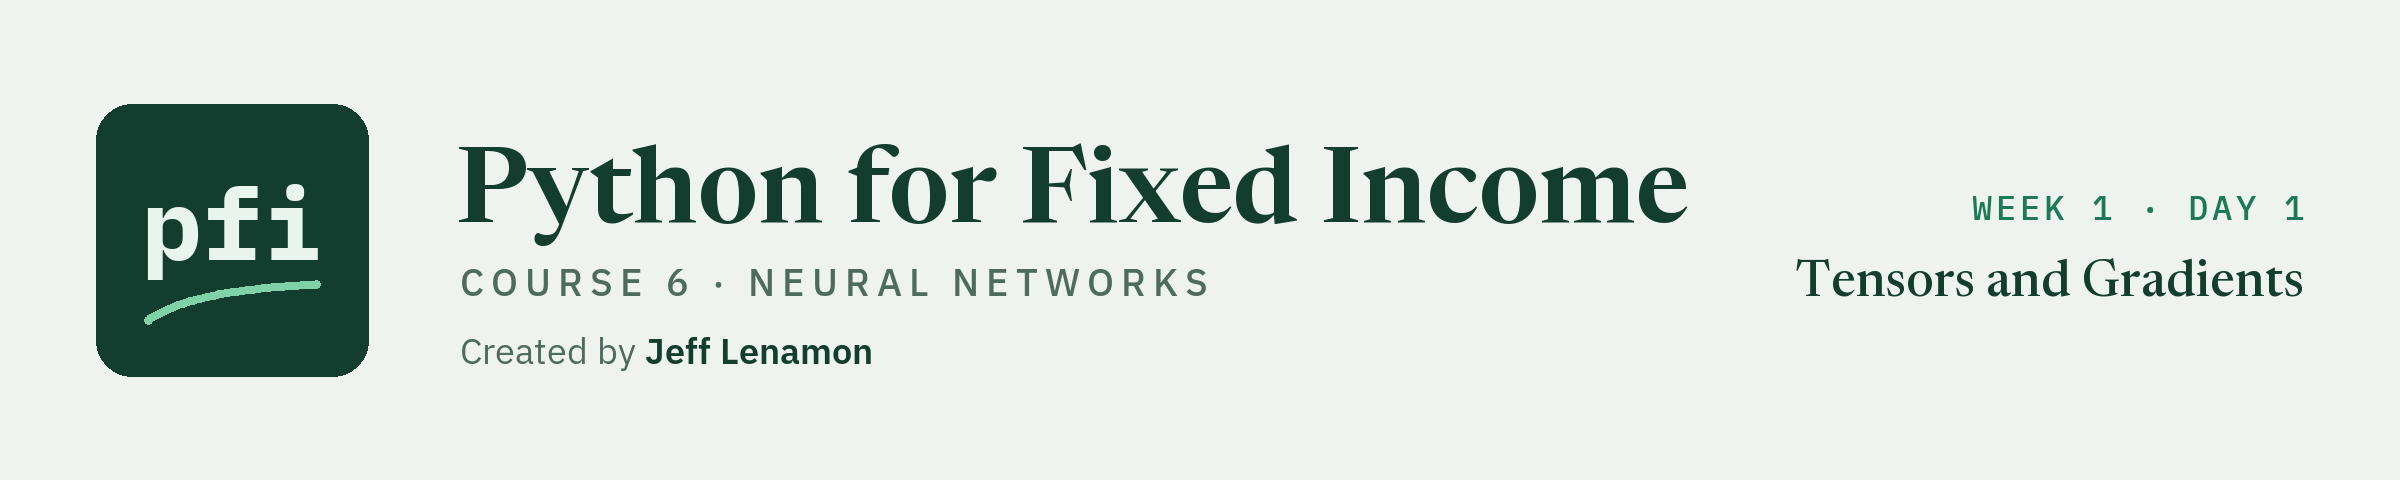

# Tensors and Gradients

Week 1, Day 1. A neural network is fitted by one idea repeated: work out which way each weight should move to lower the loss, and move it a little. Today: tensors, one neuron by hand, its gradient by hand and by TensorFlow, and gradient descent toward a logistic regression you already know.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course6_neural_networks/week1/day1/01_tensors_and_gradients.ipynb)

Courses 4 and 5 fitted models whose fitting you never had to watch: `LogisticRegression` and LightGBM did it inside `fit`. A neural network is fitted the same way in principle, but the fitting is the part you need to understand, because every setting this course changes (the learning rate, the batch size, the epochs, the optimizer) is a setting of the fitting. So Course 6 starts with the smallest network there is, **one neuron**, and fits it by hand.

One neuron on one column is a logistic regression: a weight times the column plus an intercept, put through the sigmoid. Course 4 fitted logistic regressions with scikit-learn. Today you fit one with nothing but the gradient of the loss and a loop, check every gradient against TensorFlow's, and end where scikit-learn ends.

**The card rules, as on every card day in this course.**

* **The data is real.** `credit_card_default.csv` is the UCI file Course 1 described in notebook 16 and Courses 4 and 5 modelled: 30,000 credit card accounts with payment records from April to September 2005 and an outcome for the following month. The accounts are in Taiwan in 2005, and consumer credit there differs from US credit. Nothing here describes any other market.
* **People's attributes are never features.** The file has four columns that describe people: `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE`. No model in this course uses them, and no output is grouped by them. Every model uses the other 19 columns, Course 4's; today's neuron uses one of them, `PAY_0`.
* **Course 4's split, rebuilt.** 18,000 training rows fit, 6,000 validation rows report, and Course 4's 6,000 test rows stay closed for the whole course (section 1.2).
* **A model's output is described, never acted on.** A network's output is the model probability of default in this file, or a flag at a threshold; a network fitted with class weights gives the model's score. No output of either kind is a credit decision for any person.

Today you will:

1. Recompute where Courses 4 and 5 left the card file: Course 4's logistic regression and Course 5's LightGBM.
2. State the rows line and the test-row rule, once for the whole course.
3. See which devices TensorFlow can use, and why on Windows that is the CPU.
4. Make tensors and read their shape and type.
5. Compute one neuron's output and its mean log loss by hand (`mean_log_loss`).
6. Work out the gradient by hand (`log_loss_gradient`) and check it against `tf.GradientTape`.
7. Take gradient steps by hand (`gradient_step`) until the neuron is scikit-learn's logistic regression, and see a learning rate that is too large.
8. See that one step of Keras's `fit` is one of your steps.

Q. Set up today's work folder: TensorFlow's settings, the thread settings, the seed, and the card file.

In [1]:
# today's setup: the TensorFlow and thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# TensorFlow writes start-up notices to stderr: these three lines must run before TensorFlow is imported
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These lines must run before numpy, pandas, scikit-learn, TensorFlow, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("tensorflow", "tensorflow"), ("keras", "keras"), ("lightgbm", "lightgbm"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd
import tensorflow as tf
import keras

# one thread for TensorFlow too, set before TensorFlow runs anything
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
# TensorFlow's own Python notices are turned down to errors; on Windows the one it writes is that it has no GPU
# support there (day 1 explains it)
tf.get_logger().setLevel("ERROR")
# where TensorFlow has a deterministic version of an operation, use it
tf.config.experimental.enable_op_determinism()

# the versions the saved outputs of this notebook came from (course6_neural_networks/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "tensorflow": "2.21.0", "keras": "3.15.1", "lightgbm": "4.7.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42
# Keras's seed sets Python's, numpy's, and TensorFlow's random generators at once
keras.utils.set_random_seed(SEED)

# the kinds of device TensorFlow can use on this machine
devices = sorted({device.device_type for device in tf.config.list_physical_devices()})
print(f"Devices TensorFlow can use: {', '.join(devices)}")

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course6_01_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, tensorflow 2.21.0, keras 3.15.1, lightgbm 4.7.0, matplotlib 3.11.2, pytest 9.1.1
Devices TensorFlow can use: CPU
Work folder: pfi_course6_01_bumgunr1, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv
SEED = 42


The setup cell is longer than Course 5's, and every line before `import numpy` is there for a reason. The same cell opens every Course 6 notebook.

* **Three TensorFlow settings, before TensorFlow is imported.** `KERAS_BACKEND` tells Keras to run on TensorFlow (Keras can run on others; this course uses TensorFlow only). `TF_CPP_MIN_LOG_LEVEL = "3"` and `TF_ENABLE_ONEDNN_OPTS = "0"` keep TensorFlow's start-up notices off the screen. The second also turns off one of TensorFlow's speed-ups for the CPU, oneDNN: with it off, a run on one thread and a run on every core give the same last digits for the networks this course fits.
* **Four thread settings.** Two environment variables, as in Courses 4 and 5, and two TensorFlow lines right after `import tensorflow`, before TensorFlow does anything. One thread means every run adds its numbers up in the same order, so every rerun prints the same digits.
* `tf.get_logger().setLevel("ERROR")` turns TensorFlow's own Python notices down to errors. On Windows the one it would print is about GPUs; section 1.3 says what it says.
* `tf.config.experimental.enable_op_determinism()` asks TensorFlow for the deterministic version of every operation that has one. It changes nothing on a CPU; on a GPU in Colab it is what keeps a rerun's digits the same.
* `SEED = 42`, and `keras.utils.set_random_seed(SEED)` seeds Python's, numpy's, and TensorFlow's random generators in one line. From day 2 that line runs again before every network is built, so a network's numbers never depend on what ran before it.
* The version line now shows TensorFlow and Keras, and the devices line shows what TensorFlow can run on.

Q. Write `mlkit.py`, Course 4's complete module, and `ensemblekit.py`, Course 5's complete module, both unchanged. `netkit` imports them.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))


def early_stopping_rows(X_train, y_train, fraction: float = 0.2, seed: int = 42) -> tuple:
    """Carve stopping rows out of the training rows, for early stopping, so no report row chooses the trees.

    Inputs: X_train, y_train, the training rows; fraction, the share set aside to stop on (above 0, below 0.5);
    seed, the split's seed.
    Output: X_fit, X_stop, y_fit, y_stop: a stratified split of the training rows only. Fit on X_fit and pass
    (X_stop, y_stop) as eval_set; validation and test rows are never an eval_set.
    Convention: train_test_split(test_size=fraction, stratify=y_train, random_state=seed), checked with
    mlkit.assert_disjoint.
    Raises ValueError unless 0 < fraction < 0.5.
    """
    if not 0 < fraction < 0.5:
        raise ValueError(f"fraction must be above 0 and below 0.5, not {fraction}")
    X_fit, X_stop, y_fit, y_stop = train_test_split(X_train, y_train, test_size=fraction, stratify=y_train,
                                                    random_state=seed)
    mlkit.assert_disjoint(X_fit.index, X_stop.index)
    return X_fit, X_stop, y_fit, y_stop


def scale_pos_weight(y) -> float:
    """XGBoost's weight for the rare class: negatives divided by positives.

    Input: y, the outcomes of the training rows (0 or 1).
    Output: (number of 0s) / (number of 1s). On Course 4's card training rows about 3.5.
    Convention: passed as XGBClassifier(scale_pos_weight=...); the model's output is then a score whose average
    is above the outcome rate, not a probability.
    Raises ValueError if y is empty or has no positive.
    """
    outcomes = np.asarray(y)
    positives = int((outcomes == 1).sum())
    if positives == 0:
        raise ValueError("y has no row of class 1")
    return float((outcomes == 0).sum() / positives)


def stack_inputs(models: dict, X, y, cv=None) -> pd.DataFrame:
    """The columns a stack's final model is fitted on: each base model's out-of-fold class-1 probability.

    Inputs: models, {name: classifier with predict_proba}; X, y, the training rows; cv, a splitter (default
    mlkit.cv_folds()).
    Output: a DataFrame with X's row labels and one column per model, in the order of models: each row's
    probability from the fold model that did not see it (cross_val_predict, n_jobs=1).
    Convention: what StackingClassifier(stack_method="predict_proba", cv=cv) feeds its final estimator for two
    classes. A final model fitted on in-sample outputs would learn to trust the base models too much.
    Raises ValueError if models is empty.
    """
    if not models:
        raise ValueError("models is empty")
    folds = cv if cv is not None else mlkit.cv_folds()
    columns = {name: cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
               for name, model in models.items()}
    return pd.DataFrame(columns, index=X.index)


def bootstrap_interval(y_true, proba, metric, n_boot: int = 1000, level: float = 0.95,
                       seed: int = 42) -> tuple[float, float]:
    """A percentile interval for a metric, from resampling the scored rows.

    Inputs: y_true, the outcomes of the scored rows (0 or 1); proba, the model's outputs on them; metric, a
    function metric(y_true, proba) such as roc_auc_score; n_boot, how many resamples; level, the interval's
    coverage (0.95 for a 95 percent interval); seed, the resampling seed.
    Output: (lower, upper), numpy.percentile (linear) of the n_boot values at (1 - level) / 2 and (1 + level) / 2.
    Convention: each resample draws len(y_true) rows with replacement by np.random.default_rng(seed); a resample
    holding one class only is drawn again. The interval describes the noise from which rows happened to be
    scored, not the noise from refitting the model.
    Excel: =PERCENTILE.INC(range,0.025) and =PERCENTILE.INC(range,0.975) on the pasted resampled values.
    Raises ValueError on inputs of different lengths, fewer than both classes, n_boot below 1, or level outside
    (0, 1).
    """
    actual, scores = np.asarray(y_true), np.asarray(proba, dtype=float)
    if actual.size == 0 or actual.shape != scores.shape:
        raise ValueError(f"y_true and proba must be non-empty and the same length, not {actual.size} and {scores.size}")
    if len(np.unique(actual)) < 2:
        raise ValueError("y_true must hold both classes")
    if n_boot < 1 or not 0 < level < 1:
        raise ValueError(f"n_boot must be at least 1 and level between 0 and 1, not {n_boot}, {level}")
    rng = np.random.default_rng(seed)
    values = []
    while len(values) < n_boot:
        rows = rng.integers(0, actual.size, actual.size)
        # a resample with one class has no ROC AUC; draw again
        if len(np.unique(actual[rows])) < 2:
            continue
        values.append(metric(actual[rows], scores[rows]))
    lower, upper = np.percentile(values, [100 * (1 - level) / 2, 100 * (1 + level) / 2])
    return float(lower), float(upper)


from sklearn.model_selection import cross_val_score  # one score per fold


def course4_polish_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Course 4's 4,680 training rows of the Polish bankruptcy file, without its 1,170 test rows.

    Input: frame, the 5,910 rows of polish_bankruptcy_5year.csv read with float_precision="round_trip".
    Output: X_train (Attr1 to Attr64, missing values kept) and y_train (class), 4,680 rows, 326 of them bankrupt,
    with the file's row labels. Course 4's 1,170 test rows are never returned.
    Convention: Course 4's capstone steps: exact duplicate rows dropped (5,910 to 5,850), then
    train_test_split(test_size=0.2, stratify=y, random_state=42).
    Raises ValueError if the frame does not hold 5,910 rows with a class column.
    """
    if len(frame) != 5_910 or "class" not in frame.columns:
        raise ValueError(f"frame must be the 5,910 rows of the Polish file with a class column, not {len(frame)} rows")
    unique = frame.drop_duplicates()
    X, y = unique.drop(columns="class"), unique["class"]
    # Course 4's split: the second part was its test set, dropped here
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return X_train, y_train


def nested_score(search, X, y, outer=None, scoring: str = "average_precision") -> pd.Series:
    """An honest score for a tuned model: the whole search is repeated inside each outer fold.

    Inputs: search, an unfitted RandomizedSearchCV or GridSearchCV that carries its own inner cv; X, y, the
    training rows; outer, the outer splitter (default mlkit.cv_folds()); scoring, the metric.
    Output: one score per outer fold, indexed fold_1, fold_2, ...: each fold's search tunes on the other folds
    only and is scored on its own held-out rows (cross_val_score, n_jobs=1).
    Convention: a search's best_score_ is the best of many noisy numbers and is not an honest score of the model it
    chose; the mean of this Series is.
    Raises ValueError if the search has no inner cv.
    """
    if getattr(search, "cv", None) is None:
        raise ValueError("give the search its own inner cv, for example StratifiedKFold(3, shuffle=True, random_state=42)")
    folds = outer if outer is not None else mlkit.cv_folds()
    scores = cross_val_score(search, X, y, cv=folds, scoring=scoring, n_jobs=1)
    return pd.Series(scores, index=[f"fold_{i}" for i in range(1, len(scores) + 1)], name=scoring)


def search_table(search, top: int = 5) -> pd.DataFrame:
    """A fitted search's results as a short table, best first.

    Inputs: search, a fitted RandomizedSearchCV or GridSearchCV; top, how many candidates to keep.
    Output: columns rank, mean, sd (the mean and standard deviation of the fold scores, ddof=0, as cv_results_),
    then one column per searched parameter (the param_ prefix dropped), sorted by rank.
    Excel: =AVERAGE and =STDEV.P of a candidate's five fold scores give its mean and sd (STDEV.S does not).
    Raises ValueError if the search is not fitted.
    """
    if not hasattr(search, "cv_results_"):
        raise ValueError("the search is not fitted: call fit first")
    results = pd.DataFrame(search.cv_results_)
    params = [name for name in results.columns if name.startswith("param_")]
    table = results[["rank_test_score", "mean_test_score", "std_test_score"] + params]
    table.columns = ["rank", "mean", "sd"] + [name[len("param_"):] for name in params]
    return table.sort_values("rank", kind="stable").head(top).reset_index(drop=True)


from sklearn.base import BaseEstimator, TransformerMixin  # what makes a class a scikit-learn transformer
from sklearn.utils.validation import check_is_fitted  # stops a transformer used before fit


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """A ratio of two columns that is never infinite: missing where the denominator is 0 or either side is missing.

    Inputs: numerator, denominator, two Series with the same row labels.
    Output: numerator / denominator as floats, with NaN where the denominator is 0 or either value is missing.
    Convention: a model that handles missing values (or an imputer inside a pipeline) then deals with those rows;
    an infinity would break most estimators.
    Excel: =IF(OR(B2=0,B2="",A2=""),NA(),A2/B2), where =A2/B2 alone gives #DIV/0!.
    Raises ValueError if the two Series do not have the same row labels.
    """
    if not numerator.index.equals(denominator.index):
        raise ValueError("numerator and denominator must have the same row labels")
    defined = denominator.ne(0) & numerator.notna() & denominator.notna()
    # divide only where the ratio is defined; every other row stays NaN
    return numerator.astype(float).div(denominator.astype(float).where(defined)).where(defined)


class ClipToTraining(TransformerMixin, BaseEstimator):
    """Clip each column to bounds learned from the rows it is fitted on (by default the 1st and 99th percentiles).

    Inside a pipeline, fit sees only each fold's training rows, so the bounds never come from held-out rows.
    Parameters: lower, upper, the quantiles (0 <= lower < upper <= 1).
    Fitted attributes: lower_, upper_, one bound per column (numpy.nanquantile, linear, missing values ignored);
    n_features_in_; feature_names_in_ when fitted on a DataFrame.
    transform returns a float array; a missing value stays missing.
    Excel: =PERCENTILE.INC(training_range,0.01) and 0.99 give the bounds; =MIN(MAX(x,low),high) clips.
    """

    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        if not 0 <= self.lower < self.upper <= 1:
            raise ValueError(f"need 0 <= lower < upper <= 1, not {self.lower}, {self.upper}")
        values = np.asarray(X, dtype=float)
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = values.shape[1]
        # each column's bounds, from these rows only
        self.lower_ = np.nanquantile(values, self.lower, axis=0)
        self.upper_ = np.nanquantile(values, self.upper, axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, ["lower_", "upper_"])
        values = np.asarray(X, dtype=float)
        if values.shape[1] != self.n_features_in_:
            raise ValueError(f"X has {values.shape[1]} columns, the transformer was fitted on {self.n_features_in_}")
        return np.clip(values, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["lower_", "upper_"])
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)


def class_counts_after(sampler, X, y) -> pd.Series:
    """How many rows of each class a resampler leaves: for showing what a sampler does.

    Inputs: sampler, an imbalanced-learn sampler such as SMOTE(random_state=42); X, y, rows with no missing value.
    Output: the count of each class after sampler.fit_resample(X, y), indexed by class.
    Convention: a demonstration only. Rows a model is scored on are never resampled; resampling belongs inside an
    imblearn pipeline, where cross-validation resamples each fold's training rows only.
    """
    _, y_resampled = sampler.fit_resample(X, y)
    return pd.Series(y_resampled).value_counts().sort_index()


def prior_correction(score, fitted_rate: float, true_rate: float) -> np.ndarray:
    """Move a score from a model fitted at one outcome rate back to the rate of the real rows.

    Inputs: score, the model's outputs (between 0 and 1); fitted_rate, the outcome rate of the rows the model was
    fitted on (0.5 after SMOTE to balance); true_rate, the outcome rate of the real training rows.
    Output: each score's odds multiplied by k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate)),
    turned back into a number between 0 and 1: s * k / (s * k + 1 - s).
    Convention: a closed form that assumes resampling changed only the class shares; it leaves the ranking of rows
    unchanged. Equal rates give the score back.
    Excel: k in one cell, =(t/(1-t))/(f/(1-f)), then =p*k/(p*k+1-p) filled down.
    Raises ValueError if a rate is not strictly between 0 and 1 or a score is outside [0, 1].
    """
    for name, rate in (("fitted_rate", fitted_rate), ("true_rate", true_rate)):
        if not 0 < rate < 1:
            raise ValueError(f"{name} must be strictly between 0 and 1, not {rate}")
    s = np.asarray(score, dtype=float)
    if s.size == 0 or (s < 0).any() or (s > 1).any():
        raise ValueError("score must be non-empty and between 0 and 1")
    # the factor that moves odds from the fitted rate to the true rate
    k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate))
    return s * k / (s * k + 1 - s)


import re  # whole-word search

# words that turn a description of a model into a claim about causes; a reminder, not a proof
EXPLANATION_WORDS = ["cause", "causes", "caused", "driver", "drivers", "drives", "reason", "reasons", "because"]


def shap_table(shap_values, top: int | None = None) -> pd.DataFrame:
    """Mean absolute SHAP value per feature, largest first.

    Inputs: shap_values, a shap.Explanation for one output (rows by features), for example
    shap.TreeExplainer(model)(X); top, how many features to keep (all if None).
    Output: a DataFrame indexed by feature with columns mean_abs_shap (the average size of the feature's
    contribution to the model's log-odds, in log-odds) and rank (1 = largest).
    Convention: a SHAP value describes how the model's output for a row splits across features; it is not the
    effect of changing a feature and not a cause.
    Excel: =AVERAGE(ABS(column)) on a pasted column of SHAP values.
    Raises ValueError if the values are not one row per observation and one column per feature.
    """
    values = np.asarray(shap_values.values, dtype=float)
    if values.ndim != 2 or values.shape[1] != len(shap_values.feature_names):
        raise ValueError(f"expected rows by features, got shape {values.shape}")
    table = pd.DataFrame({"mean_abs_shap": np.abs(values).mean(axis=0)},
                         index=pd.Index(shap_values.feature_names, name="feature"))
    table = table.sort_values("mean_abs_shap", ascending=False, kind="stable")
    table["rank"] = np.arange(1, len(table) + 1)
    return table if top is None else table.head(top)


def assert_additive(shap_values, raw_score, tol: float = 1e-9) -> None:
    """Stop unless each row's SHAP values add up to the model's raw output (log-odds).

    Inputs: shap_values, a shap.Explanation for one output; raw_score, the model's log-odds for the same rows
    (LightGBM: predict(X, raw_score=True); XGBoost: predict(X, output_margin=True)); tol, the largest gap allowed
    (1e-9 for LightGBM; 1e-5 for XGBoost, which computes in float32).
    Output: None when base value + the row's SHAP values equals raw_score in every row within tol.
    Convention: the contributions add up in log-odds, not in probability; mlkit.logistic_probability turns the sum
    into the model's probability.
    Raises AssertionError naming the largest gap and its row position, and ValueError on lengths that differ.
    """
    values = np.asarray(shap_values.values, dtype=float)
    raw = np.asarray(raw_score, dtype=float)
    if values.ndim != 2 or values.shape[0] != raw.size:
        raise ValueError(f"shap_values has {values.shape[0]} rows and raw_score {raw.size}")
    # base value plus the row's contributions, against the model's own log-odds
    gaps = np.abs(np.asarray(shap_values.base_values, dtype=float) + values.sum(axis=1) - raw)
    worst = int(np.argmax(gaps))
    if gaps[worst] > tol:
        raise AssertionError(f"SHAP values do not add up to raw_score: largest gap {gaps[worst]:.3g} at row "
                             f"position {worst} (tolerance {tol:g}); raw_score must be log-odds, not a probability")


def assert_described(text: str) -> None:
    """Stop if a written description uses a forecast word or a cause word.

    Input: text, a description of what a model shows.
    Output: None if the text passes mlkit.assert_descriptive and holds no word of EXPLANATION_WORDS as a whole word,
    in any case.
    Convention: the lists are a reminder, not a proof. "because" is on the list so the writer looks again at every
    causal sentence; a description that needs it rewrites the sentence.
    Raises ValueError naming the words found.
    """
    mlkit.assert_descriptive(text)
    found = [word for word in EXPLANATION_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses cause or explanation words: {found}")

Writing ensemblekit.py


* Courses 4 and 5 left two finished modules. Course 6 never changes them. Today's new module, `netkit.py`, **imports** both and uses their functions rather than writing them again: `ensemblekit.course4_card_rows` for the card rows, `mlkit.classification_metrics` for flags, and from day 2 Course 5's stopping rows.

## 1.1 Where Courses 4 and 5 Left the Card File

Before the first network, the two numbers it will be judged against: Course 4's logistic regression and Course 5's LightGBM, on the same rows.

Q. Import the two earlier modules.

In [4]:
# Python finds a module in the folders listed in sys.path: put the work folder first
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

print(f"mlkit and ensemblekit imported; card rows from {ensemblekit.course4_card_rows.__name__}")

mlkit and ensemblekit imported; card rows from course4_card_rows


Q. Load the card accounts and take Course 4's training and validation rows.

In [5]:
# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")

# Course 4's split, rebuilt by Course 5's function: training and validation rows only, with the 19 model columns
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
# the four columns that describe people are never features: stop if one slips in
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"

print(f"training rows: {len(X_train):,}, default rate {y_train.mean():.2%}")
print(f"validation rows: {len(X_valid):,}, default rate {y_valid.mean():.2%}")
print(f"features: {X_train.shape[1]}")

training rows: 18,000, default rate 22.12%
validation rows: 6,000, default rate 22.12%
features: 19


* 18,000 and 6,000 rows, both with a default rate of 22.12 percent, because both of Course 4's cuts were stratified on the outcome.

Q. Fit Course 4's logistic regression and Course 5's LightGBM on the training rows, and score both on the validation rows.

In [6]:
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Course 4's logistic regression: scaled inside a pipeline, fitted on the training rows
logistic = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X_train, y_train)
# Course 5's LightGBM on the card file: 300 trees at learning rate 0.05, one thread, quiet
light = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=SEED, n_jobs=1, verbose=-1).fit(X_train, y_train)

proba_logistic = logistic.predict_proba(X_valid)[:, 1]
proba_light = light.predict_proba(X_valid)[:, 1]
for name, proba in [("Course 4 logistic regression", proba_logistic), ("Course 5 LightGBM", proba_light)]:
    print(f"{name}: validation ROC AUC {roc_auc_score(y_valid, proba):.4f}, "
          f"average precision {average_precision_score(y_valid, proba):.4f}")

Course 4 logistic regression: validation ROC AUC 0.7190, average precision 0.4946
Course 5 LightGBM: validation ROC AUC 0.7725, average precision 0.5434


**Rows.** Every model on the card file in this notebook is fitted on Course 4's 18,000 training rows and scored on Course 4's 6,000 validation rows; Course 4's 6,000 test rows are never scored in this course.

* Both outputs are the model probability of default in this file. The logistic regression gives Course 4's 0.7190 and 0.4946, and LightGBM Course 5's 0.7725 and 0.5434, so the rows are the earlier courses' rows to the account.
* These are the bar. Day 5 puts a network beside both, on these validation rows, with intervals, and the course says what the numbers support. Nothing today is a network yet; today is how a network is fitted.

## 1.2 The Rows Line and the Test-Row Rule

Every card notebook in Course 6 states its rows in one line under the first model it scores, as you saw above. From day 2, when networks need rows to stop on, the line reads:

**Rows.** Every network on the card file in this notebook is fitted on Course 4's 18,000 training rows (14,400 to fit and 3,600 to stop or choose) and scored on Course 4's 6,000 validation rows; Course 4's 6,000 test rows are never scored in this course.

Behind it is one rule for the whole course, the same rule Course 5 kept:

**The test-row rule.** A row that an earlier course used as a test row is never scored in Course 6. On the card file that means Course 4's 6,000 test rows. Course 4 opened them once, on day 10, and reported on them; scoring them again for a new round of models, after their numbers have been seen, would turn them into rows the course chooses against. `ensemblekit.course4_card_rows`, Course 5's function, rebuilds Course 4's split with the same two cuts and the same seed and returns only the training and validation rows, so a closed row cannot be scored by accident. The validation rows were used in Course 4 to choose and in Course 5 to report; Course 6 chooses nothing on them. From day 2 every setting is chosen on rows carved from the training rows (a stratified fifth, 3,600 rows, to stop or choose on) or by folds inside them, and the validation rows report once per chosen model, labelled validation, never test.

The rule is enforced in code, not by memory: `course4_card_rows` never returns a closed row, and Course 5's tests prove it. Course 6's own files (the benchmark bonds, the Polish companies, the Treasury curve, and the Taiwan companies of the capstone) each get their own line on the day they first appear.

## 1.3 Devices: TensorFlow, Keras, and the CPU

**TensorFlow** is the library that does the arithmetic of a network: it stores numbers as tensors, multiplies them, and works out gradients. **Keras** is the library you build networks with: layers, losses, optimizers, `fit`. Keras runs its arithmetic on TensorFlow here. Courses 4 and 5 never asked what hardware a model ran on; for networks the question comes up, so it is answered once, today.

Q. Which devices can TensorFlow use on this machine?

In [7]:
# every device TensorFlow can use here, and the GPUs among them
devices_found = tf.config.list_physical_devices()
gpus = tf.config.list_physical_devices("GPU")
for device in devices_found:
    print(f"{device.device_type}: {device.name}")
print(f"GPUs TensorFlow can use here: {len(gpus)}")

CPU: /physical_device:CPU:0
GPUs TensorFlow can use here: 0


* One device, the CPU, and no GPU.

**Devices.** TensorFlow runs a network on the devices it can use: the CPU always, and a GPU (a graphics card) where it supports one. On native Windows it supports none, and it says so itself the first time anything lists the devices: "TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin." (source: `tensorflow/python/framework/config.py` in TensorFlow 2.21.0, read for this course on 2026-10-06). The setup cell turns TensorFlow's own notices down to errors, which hides that one; this paragraph is what it says. The course uses neither of the two routes it names.

Colab is the other route to a GPU. Its FAQ says Colab "provides free of charge access to computing resources, including GPUs and TPUs", and that "Colab resources are not guaranteed and not unlimited, and usage limits sometimes fluctuate." The setting is under Runtime, then Change Runtime Type, then Hardware Accelerator; the FAQ names it where it says how to turn an accelerator off: "Choose Runtime > Change Runtime Type and set Hardware Accelerator to None" (source: Colab's FAQ, https://research.google.com/colaboratory/faq.html, read 2026-10-06). Nothing in this course needs a GPU. Every notebook runs on the CPU within its time budget, and nothing here was run or timed on a GPU. Day 4 says where a GPU would help.

## 1.4 Tensors

A **tensor** is TensorFlow's array: a block of numbers with a **shape** (how many along each axis) and a **dtype** (the kind of number). It is numpy's array under another name, with one addition that matters today: TensorFlow can work out gradients of anything computed from tensors.

Q. Make three tensors: one number, one column of the card file, and five card rows. What shape and dtype does each get?

In [8]:
# one Python number: shape () (no axes), and float32, TensorFlow's default for a decimal number
one_number = tf.constant(0.5)
print(f"tf.constant(0.5): shape {one_number.shape}, dtype {one_number.dtype.name}")

# a numpy array of float64 keeps its dtype: one axis of 18,000 numbers
pay_0 = tf.constant(X_train["PAY_0"].to_numpy(dtype="float64"))
print(f"PAY_0 of the training rows: shape {pay_0.shape}, dtype {pay_0.dtype.name}")

# five card rows of 19 columns: two axes, rows then columns; the file's whole numbers come in as int64
batch = tf.constant(X_train.iloc[:5].to_numpy())
print(f"five card rows: shape {batch.shape}, dtype {batch.dtype.name}")

tf.constant(0.5): shape (), dtype float32
PAY_0 of the training rows: shape (18000,), dtype float64
five card rows: shape (5, 19), dtype int64


* A shape lists the length of each axis: `()` for one number, `(18000,)` for a column, `(5, 19)` for five rows of 19 columns. A batch of rows is always rows first, then columns, as in a pandas frame or a range of cells in Excel.
* `tf.constant(0.5)` is **float32**, single precision, about 7 significant digits. A float64 numpy array stays **float64**, about 16 digits. Networks are fitted in float32 (Keras's default), and that is why this course compares a Keras result with a hand result "within 1e-6", while two float64 results are compared "within 1e-12".

Q. Multiply the float32 number by the float64 column. Then cast it first.

In [9]:
# TensorFlow does not convert dtypes for you: a float32 times a float64 stops with an error
try:
    one_number * pay_0
except tf.errors.InvalidArgumentError as error:
    print(f"{type(error).__name__}: {str(error).split(' [Op')[0]}")

# cast the number to float64 first, then the arithmetic runs element by element, as in numpy
z = tf.cast(one_number, tf.float64) * pay_0 - 1.0
print(f"0.5 * PAY_0 - 1 for the first five rows: {z.numpy()[:5].tolist()}")
# .numpy() turns a tensor back into a numpy array
print(f"z.numpy() is a {type(z.numpy()).__name__} of shape {z.numpy().shape}")
# keras.ops holds Keras's own versions of the same operations; the sigmoid of 0 is one half
print(f"keras.ops.sigmoid(0.0) = {float(keras.ops.sigmoid(tf.constant(0.0))):.4f}")

InvalidArgumentError: cannot compute Mul as input #1(zero-based) was expected to be a float tensor but is a double tensor
0.5 * PAY_0 - 1 for the first five rows: [-1.0, -1.0, -1.5, -1.0, -1.0]
z.numpy() is a ndarray of shape (18000,)
keras.ops.sigmoid(0.0) = 0.5000


* numpy would quietly turn the result into float64; TensorFlow stops instead (a "float tensor" in its message is float32, a "double tensor" float64). Cast one side with `tf.cast` and the line runs. The error is caught here with `except tf.errors.InvalidArgumentError`, naming the error, so the notebook carries on.
* `keras.ops` is Keras's own set of operations (`keras.ops.sigmoid`, `keras.ops.mean`, and the rest), which run on whichever backend Keras uses. This course writes `tf.` for tensors and gradients, and meets `keras.ops` again only where Keras's own code uses it.

## 1.5 One Neuron by Hand

A **neuron** takes its inputs, multiplies each by a **weight**, adds an **intercept** (Keras names it the bias), and puts the total through an **activation**. With one input x, weight w, and intercept b:

* z = b + w x, a straight line in x;
* the output p = 1 / (1 + e^(-z)), the **sigmoid** of z, which squeezes any z into the range 0 to 1.

That is exactly Course 4's logistic regression on one column. Fitting the neuron means choosing w and b. Start anywhere: w = 0.5, b = -1.0, on `PAY_0`, the most recent repayment status, which runs from -2 to 8 in the training rows.

Q. Compute z and the neuron's output for every training row.

In [10]:
# the starting weight and intercept: an arbitrary place to start
w_start, b_start = np.array([0.5]), -1.0

# PAY_0 as a column of rows (rows by one column) and the outcomes as float64 arrays
X_pay = X_train[["PAY_0"]].to_numpy(dtype="float64")
outcome = y_train.to_numpy(dtype="float64")

# z = b + w x for every row, then the sigmoid
z_start = X_pay @ w_start + b_start
p_start = 1 / (1 + np.exp(-z_start))

first = pd.DataFrame({"PAY_0": X_train["PAY_0"].iloc[:5], "default": y_train.iloc[:5], "z": z_start[:5],
                      "output": p_start[:5]})
print(first.round(4).to_string())
print(f"mean output {p_start.mean():.4f} against the default rate {outcome.mean():.4f}")

       PAY_0  default    z  output
10574      0        0 -1.0  0.2689
11330      0        0 -1.0  0.2689
7127      -1        0 -1.5  0.1824
25150      0        0 -1.0  0.2689
6000       0        0 -1.0  0.2689
mean output 0.2795 against the default rate 0.2212


* `X_pay @ w_start` multiplies each row by its weight: with one column it is just w times `PAY_0`. With 19 columns the same line would multiply each row's 19 numbers by 19 weights and add them up, Excel's `SUMPRODUCT` across a row.
* The starting neuron gives an output of 0.2795 on average, against a default rate of 0.2212: too high, and it does not yet separate the accounts much. The next question is how to say "how wrong" in one number.

**The loss.** For one account with outcome y and output p, the **log loss** is -(y ln p + (1 - y) ln(1 - p)): small when the output is near the outcome, large when it is confidently wrong. The **mean log loss** over the rows is what Course 4's logistic regression made as small as possible, and what Keras names `binary_crossentropy`. Keras keeps every p at least 1e-7 away from 0 and 1 before taking logarithms, so a loss is never infinite; the function does the same.

Q. Start `netkit.py` with `mean_log_loss`. Read the docstring first.

In [11]:
%%writefile netkit.py
"""netkit: the pieces of neural networks that Keras leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 6: Neural Networks. It imports mlkit (Course 4's module) and
ensemblekit (Course 5's module) and never changes either.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one. Every function that builds a Keras model calls
  keras.utils.set_random_seed(seed) first, so a model's numbers do not depend on what ran before it.
- Keras runs quietly: verbose=0 on every fit, predict, and evaluate.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 6 never scores a row that an earlier course used as a test row: rows come from ensemblekit.course4_*_rows.
- Rows that fit a network, rows that stop or choose, and rows that report a result are kept apart. A scaler is
  fitted on the fit rows only (fit_arrays).
- Changes and errors on the Treasury curve are in basis points (bp).
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import os

# TensorFlow reads these when it is imported. setdefault keeps whatever a notebook's setup cell already set, and
# quiets TensorFlow's start-up notices when the tests run from PowerShell.
os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")

import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
import tensorflow as tf  # tensors and automatic gradients
import keras  # networks: layers, optimizers, losses

import ensemblekit  # Course 5's module: the card, benchmark, and Polish rows, stopping rows, mae_bp
import mlkit  # Course 4's module: folds, thresholds, metrics, and the no-leak checks


def _labels_and_scores(y, p) -> tuple[np.ndarray, np.ndarray]:
    """y and p as float64 arrays of the same length, y holding only 0 and 1; raises ValueError otherwise."""
    labels = np.asarray(y, dtype=float).ravel()
    scores = np.asarray(p, dtype=float).ravel()
    if labels.size == 0 or labels.size != scores.size:
        raise ValueError(f"y and p must be non-empty and the same length, not {labels.size} and {scores.size}")
    if not np.isin(labels, (0.0, 1.0)).all():
        raise ValueError("y must hold only 0 and 1")
    return labels, scores


def mean_log_loss(y, p, epsilon: float = 1e-7) -> float:
    """The mean log loss (binary cross-entropy) of outputs p for outcomes y.

    Inputs: y, outcomes (0 or 1); p, the model's outputs, between 0 and 1, the same length; epsilon, how far from 0
    and 1 each output is clipped.
    Output: mean of -(y ln p + (1 - y) ln(1 - p)), with p clipped to [epsilon, 1 - epsilon] as Keras clips (its
    default epsilon is 1e-7). Equals sklearn.metrics.log_loss within 1e-12 when no output is clipped.
    Excel: =-(B2*LN(C2)+(1-B2)*LN(1-C2)) filled down, then =AVERAGE of the column.
    Raises ValueError on lengths that differ or labels other than 0 and 1.
    """
    labels, scores = _labels_and_scores(y, p)
    # keep every output inside (0, 1), so no logarithm is of 0
    clipped = np.clip(scores, epsilon, 1 - epsilon)
    return float(np.mean(-(labels * np.log(clipped) + (1 - labels) * np.log(1 - clipped))))

Writing netkit.py


* The header sets the three TensorFlow settings with `os.environ.setdefault`, which keeps whatever the setup cell already set. When you run the tests from PowerShell, where no setup cell ran, it keeps TensorFlow quiet there too.
* `netkit` imports `mlkit` and `ensemblekit`: Course 6's module is built on Courses 4 and 5, never beside them.
* `_labels_and_scores` starts with an underscore: a helper for the module's own functions, not for use from a notebook. It turns both inputs into float64 arrays and stops on lengths that differ or labels other than 0 and 1.
* `np.clip(scores, epsilon, 1 - epsilon)` is the clip Keras applies.

Q. Start `test_netkit.py` with two tests: agreement with scikit-learn, and the clip.

In [12]:
%%writefile test_netkit.py
"""Tests for netkit.py.

Expected values come from TensorFlow, Keras, or scikit-learn on the same inputs, or from small examples worked by
hand. Every test uses small seeded arrays: no course data file, no network connection.
Run from this folder with:  python -m pytest
"""
import keras
import numpy as np
import pytest
import tensorflow as tf
from sklearn.metrics import log_loss

import netkit

SEED = 42


def small_rows(n: int = 200, k: int = 3) -> tuple[np.ndarray, np.ndarray]:
    """n seeded rows of k standard normal columns and 0/1 outcomes that depend on the first column."""
    rng = np.random.default_rng(SEED)
    X = rng.normal(size=(n, k))
    y = (X[:, 0] + rng.normal(size=n) > 0.5).astype(float)
    return X, y


def test_mean_log_loss_matches_sklearn():
    rng = np.random.default_rng(SEED)
    y = rng.integers(0, 2, 50)
    p = rng.uniform(0.05, 0.95, 50)
    assert netkit.mean_log_loss(y, p) == pytest.approx(log_loss(y, p), abs=1e-12)
    with pytest.raises(ValueError):
        netkit.mean_log_loss([0, 1], [0.5])
    with pytest.raises(ValueError):
        netkit.mean_log_loss([0, 2], [0.5, 0.5])


def test_mean_log_loss_clips_like_keras():
    # an output of exactly 0 for an outcome of 1 is clipped to 1e-7, as Keras clips, so the loss is finite
    y, p = np.array([1.0, 0.0]), np.array([0.0, 0.0])
    expected = -(np.log(1e-7) + np.log(1 - 1e-7)) / 2
    assert netkit.mean_log_loss(y, p) == pytest.approx(expected, rel=1e-12)
    keras_loss = keras.losses.binary_crossentropy(y.astype("float32"), p.astype("float32"))
    assert netkit.mean_log_loss(y, p) == pytest.approx(float(keras_loss), rel=1e-6)

Writing test_netkit.py


* netkit's tests use small seeded arrays, never a course data file, so every test is fast and none depends on a split. The clip test gives an output of exactly 0 to an account that defaulted: unclipped, the log loss would be infinite.

Q. Import the modules, and run the tests.

In [13]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit
import netkit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)
importlib.reload(netkit)

# the functions defined in netkit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(netkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "netkit" and not name.startswith("_")]
print(f"netkit functions: {functions}")

netkit functions: ['mean_log_loss']


In [14]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_netkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..                                                                       [100%]
2 passed in 3.94s



* `2 passed`.

Q. What is the starting neuron's mean log loss on the training rows?

In [15]:
# the mean log loss of the starting neuron, by netkit and by scikit-learn
loss_start = netkit.mean_log_loss(outcome, p_start)
print(f"mean log loss at w = 0.5, b = -1.0: {loss_start:.4f}")
print(f"equal to scikit-learn's log_loss within 1e-12: {abs(loss_start - log_loss(outcome, p_start)) < 1e-12}")

# the same outputs from TensorFlow's sigmoid, on a float64 tensor
p_tf = tf.sigmoid(tf.constant(z_start)).numpy()
print(f"TensorFlow's sigmoid equal to the numpy formula within 1e-12: {np.abs(p_tf - p_start).max() < 1e-12}")

mean log loss at w = 0.5, b = -1.0: 0.4876
equal to scikit-learn's log_loss within 1e-12: True
TensorFlow's sigmoid equal to the numpy formula within 1e-12: True


* 0.4876. Fitting the neuron means moving w and b to make this number smaller. Course 4's logistic regression on `PAY_0` reaches 0.4720; section 1.7 gets there by hand.

## 1.6 The Gradient by Hand, and by TensorFlow

To lower the loss you need to know, for each weight, which way to move it and how strongly the loss responds: the **gradient**, the slope of the mean log loss with respect to each weight, holding the others fixed.

For the sigmoid and the log loss the slope works out to something short. For one account, the slope of its log loss with respect to z is p - y: the output minus the outcome. Since z = b + w x, the slope with respect to w is (p - y) x and with respect to b is p - y. The mean log loss is an average over the rows, so its gradient is the average of these:

* for the weight: the average of (p - y) x over the rows;
* for the intercept: the average of (p - y).

A negative slope means "increase this weight to lower the loss"; a positive one means "decrease it".

Q. Add `log_loss_gradient` to `netkit.py`.

In [16]:
%%writefile -a netkit.py


def _neuron_inputs(w, b: float, X, y) -> tuple[np.ndarray, float, np.ndarray, np.ndarray]:
    """w, X, y as float64 arrays that line up with each other; raises ValueError otherwise."""
    weights = np.asarray(w, dtype=float).ravel()
    rows = np.asarray(X, dtype=float)
    if rows.ndim != 2 or rows.shape[0] == 0:
        raise ValueError(f"X must be a non-empty 2-D array of rows by columns, not shape {rows.shape}")
    if rows.shape[1] != weights.size:
        raise ValueError(f"X has {rows.shape[1]} columns but w has {weights.size} weights")
    labels, _ = _labels_and_scores(y, np.zeros(rows.shape[0]))
    return weights, float(b), rows, labels


def log_loss_gradient(w, b: float, X, y) -> tuple[np.ndarray, float]:
    """The gradient of the mean log loss of one sigmoid neuron, worked by hand.

    Inputs: w, one weight per column of X; b, the intercept; X, the rows (rows by columns); y, the outcomes (0 or 1).
    Output: (gradient for the weights, gradient for the intercept), in float64: ((p - y) @ X / n, mean(p - y)),
    where p = 1 / (1 + exp(-(X @ w + b))) and n is the number of rows.
    Convention: the gradient is averaged over the rows, as Keras averages the loss over a batch. Equals
    tf.GradientTape on float64 tensors within 1e-12.
    Excel: =SUMPRODUCT(C2:C18001-B2:B18001,A2:A18001)/ROWS(A2:A18001) for a weight and
    =SUMPRODUCT(C2:C18001-B2:B18001)/ROWS(A2:A18001) for the intercept.
    Raises ValueError if the shapes do not line up or y holds labels other than 0 and 1.
    """
    weights, intercept, rows, labels = _neuron_inputs(w, b, X, y)
    # the neuron's output for each row, then how far it is from the outcome
    p = 1 / (1 + np.exp(-(rows @ weights + intercept)))
    error = p - labels
    return error @ rows / rows.shape[0], float(error.mean())

Appending to netkit.py


* `_neuron_inputs`, another helper, checks the shapes line up: `X` is rows by columns and `w` has one weight per column. So you pass `X_train[["PAY_0"]]` (a frame of one column, two square brackets), not `X_train["PAY_0"]` (a column on its own).
* `error @ rows / rows.shape[0]` is the average of (p - y) x for every column at once. The docstring says the gradient is **averaged** over the rows, as Keras averages the loss over a batch. That one word comes back in the AI check.

Q. Add two tests: agreement with `tf.GradientTape`, and two rows worked by hand.

In [17]:
%%writefile -a test_netkit.py


def test_log_loss_gradient_matches_tape():
    X, y = small_rows()
    w, b = np.array([0.5, -0.25, 0.1]), -1.0
    weights = tf.Variable(w)
    intercept = tf.Variable(b, dtype=tf.float64)
    with tf.GradientTape() as tape:
        p = tf.sigmoid(tf.linalg.matvec(tf.constant(X), weights) + intercept)
        loss = tf.reduce_mean(-(y * tf.math.log(p) + (1 - y) * tf.math.log(1 - p)))
    tape_w, tape_b = tape.gradient(loss, [weights, intercept])
    hand_w, hand_b = netkit.log_loss_gradient(w, b, X, y)
    assert np.allclose(hand_w, tape_w.numpy(), rtol=0, atol=1e-12)
    assert hand_b == pytest.approx(float(tape_b), abs=1e-12)


def test_log_loss_gradient_hand_case():
    # two rows, one column, w = 0 and b = 0: both outputs are 0.5
    # weight: ((0.5 - 1) * 2 + (0.5 - 0) * 4) / 2 = 0.5; intercept: ((0.5 - 1) + (0.5 - 0)) / 2 = 0
    gradient_w, gradient_b = netkit.log_loss_gradient([0.0], 0.0, [[2.0], [4.0]], [1, 0])
    assert gradient_w.tolist() == pytest.approx([0.5], abs=1e-12)
    assert gradient_b == pytest.approx(0.0, abs=1e-12)
    with pytest.raises(ValueError):
        netkit.log_loss_gradient([0.0, 1.0], 0.0, [[2.0], [4.0]], [1, 0])

Appending to test_netkit.py


* The hand case is small enough to check on paper: two rows with x = 2 and x = 4, outcomes 1 and 0, and w = b = 0, so both outputs are 0.5. The weight's gradient is ((0.5 - 1) 2 + (0.5 - 0) 4) / 2 = 0.5.

Q. Reload `netkit` and run the tests.

In [18]:
# the file changed, so reload before using the new function
importlib.reload(netkit)
print(f"log_loss_gradient in netkit: {hasattr(netkit, 'log_loss_gradient')}")

log_loss_gradient in netkit: True


In [19]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_netkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

....                                                                     [100%]
4 passed in 3.87s



* `4 passed`.

Q. What is the gradient at the starting neuron?

In [20]:
# the gradient of the mean log loss at w = 0.5, b = -1.0, worked by hand
gradient_w, gradient_b = netkit.log_loss_gradient(w_start, b_start, X_pay, outcome)
print(f"gradient for the weight: {gradient_w[0]:.6f}")
print(f"gradient for the intercept: {gradient_b:.6f}")

gradient for the weight: -0.033916
gradient for the intercept: 0.058284


* The weight's gradient is negative (-0.033916): raising w lowers the loss, so accounts with a worse repayment status should get a higher output. The intercept's is positive (0.058284): lowering b lowers the loss, which fits the outputs being too high on average (0.2795 against 0.2212). The intercept's gradient is exactly that gap: the average of p - y.

**TensorFlow's way.** TensorFlow can work out the same gradient without being told the formula. Inside a `tf.GradientTape` block it records every operation on `tf.Variable`s; `tape.gradient(loss, [weights, intercept])` then runs back through the record and returns the slope of the loss with respect to each variable. This is called automatic differentiation.

Q. Compute the mean log loss inside a gradient tape, in float64, and compare TensorFlow's gradient with yours.

In [21]:
# tf.Variable: a tensor TensorFlow can change and take gradients with respect to
weights = tf.Variable(w_start)
intercept = tf.Variable(b_start, dtype=tf.float64)

# the tape records every operation inside the block
with tf.GradientTape() as tape:
    output = tf.sigmoid(tf.linalg.matvec(tf.constant(X_pay), weights) + intercept)
    loss = tf.reduce_mean(-(outcome * tf.math.log(output) + (1 - outcome) * tf.math.log(1 - output)))

# the slope of the loss with respect to each variable
tape_w, tape_b = tape.gradient(loss, [weights, intercept])
print(f"TensorFlow, float64: weight {tape_w.numpy()[0]:.6f}, intercept {float(tape_b):.6f}, loss {float(loss):.4f}")
same_64 = abs(tape_w.numpy()[0] - gradient_w[0]) < 1e-12 and abs(float(tape_b) - gradient_b) < 1e-12
print(f"hand gradient equal to TensorFlow's within 1e-12: {same_64}")

TensorFlow, float64: weight -0.033916, intercept 0.058284, loss 0.4876
hand gradient equal to TensorFlow's within 1e-12: True


* The same two numbers to 12 decimal places: the formula for (p - y) x is right, and TensorFlow found it on its own from the loss.

Q. Do the same in float32, the precision Keras fits networks in.

In [22]:
# the same calculation with float32 tensors
weights_32 = tf.Variable(w_start.astype("float32"))
intercept_32 = tf.Variable(np.float32(b_start))
outcome_32 = outcome.astype("float32")
with tf.GradientTape() as tape:
    output_32 = tf.sigmoid(tf.linalg.matvec(tf.constant(X_pay.astype("float32")), weights_32) + intercept_32)
    loss_32 = tf.reduce_mean(-(outcome_32 * tf.math.log(output_32) + (1 - outcome_32) * tf.math.log(1 - output_32)))
tape_w32, tape_b32 = tape.gradient(loss_32, [weights_32, intercept_32])
same_32 = abs(float(tape_w32.numpy()[0]) - gradient_w[0]) < 1e-6 and abs(float(tape_b32) - gradient_b) < 1e-6
print(f"hand gradient (float64) equal to TensorFlow's in float32 within 1e-6: {same_32}")

hand gradient (float64) equal to TensorFlow's in float32 within 1e-6: True


* In float32 the numbers agree to about 7 significant digits, the most float32 holds, so the comparison is "within 1e-6". The course prints comparisons this way, as a stated tolerance and `True`, never as a raw gap.
* For one neuron the hand formula is two lines. For a network of thousands of weights in layers, nobody writes the formulas: the tape works them out. That is what Keras uses inside `fit`.

## 1.7 Gradient Descent by Hand

**Gradient descent** repeats one step: move every weight a little in the direction that lowers the loss, w becomes w - (learning rate) x (gradient), then work out the gradient again at the new weights. The **learning rate** says how far each step goes. Using every row for each gradient is **full-batch** gradient descent; day 4 meets mini-batches.

Q. Add `gradient_step` to `netkit.py`, and its two tests.

In [23]:
%%writefile -a netkit.py


def gradient_step(w, b: float, X, y, learning_rate: float) -> tuple[np.ndarray, float]:
    """One full-batch step of gradient descent for one sigmoid neuron.

    Inputs: w, b, X, y as log_loss_gradient; learning_rate, the size of the step (above 0).
    Output: (w - learning_rate * gradient for the weights, b - learning_rate * gradient for the intercept).
    Convention: a learning rate that is too large makes the loss rise instead of fall.
    Excel: =$H$2-$H$5*$H$7 for each weight, with the gradient in its own cell.
    Raises ValueError unless learning_rate > 0, and as log_loss_gradient.
    """
    if not learning_rate > 0:
        raise ValueError(f"learning_rate must be above 0, not {learning_rate}")
    gradient_w, gradient_b = log_loss_gradient(w, b, X, y)
    return np.asarray(w, dtype=float).ravel() - learning_rate * gradient_w, float(b) - learning_rate * gradient_b

Appending to netkit.py


In [24]:
%%writefile -a test_netkit.py


def test_gradient_step_lowers_loss():
    X, y = small_rows()
    w, b = np.zeros(3), 0.0

    def loss(w, b):
        return netkit.mean_log_loss(y, 1 / (1 + np.exp(-(X @ w + b))))

    before = loss(w, b)
    for _ in range(20):
        w, b = netkit.gradient_step(w, b, X, y, learning_rate=0.5)
    assert loss(w, b) < before


def test_gradient_step_rejects_learning_rate():
    X, y = small_rows(10)
    for rate in (0.0, -0.1):
        with pytest.raises(ValueError):
            netkit.gradient_step(np.zeros(3), 0.0, X, y, learning_rate=rate)

Appending to test_netkit.py


* The step refuses a learning rate of 0 or below with `ValueError`: a step of size 0 goes nowhere, and a negative one climbs the loss.
* `test_gradient_step_lowers_loss` takes 20 steps on small seeded rows and asserts the loss fell.

Q. Reload and run all of today's tests.

In [25]:
importlib.reload(netkit)
print(f"gradient_step in netkit: {hasattr(netkit, 'gradient_step')}")

gradient_step in netkit: True


In [26]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_netkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

......                                                                   [100%]
6 passed in 3.96s



* `6 passed`: the module's three functions, tested.

Q. Take 100 steps at learning rate 1.0 from the starting neuron, and record the weights and the loss after each.

In [27]:
learning_rate = 1.0
# step 0 is the starting neuron
path = [(0, b_start, w_start[0], loss_start)]
w, b = w_start, b_start
for step in range(1, 101):
    w, b = netkit.gradient_step(w, b, X_pay, outcome, learning_rate)
    loss_now = netkit.mean_log_loss(outcome, 1 / (1 + np.exp(-(X_pay @ w + b))))
    path.append((step, b, w[0], loss_now))
path = pd.DataFrame(path, columns=["step", "intercept", "weight", "mean log loss"]).set_index("step")
w_hand, b_hand = w[0], b
print(path.loc[[0, 1, 2, 5, 10, 20, 50, 100]].round(6).to_string())

      intercept    weight  mean log loss
step                                    
0     -1.000000  0.500000       0.487621
1     -1.058284  0.533916       0.483442
2     -1.107029  0.562693       0.480484
5     -1.212828  0.627347       0.475651
10    -1.310600  0.691431       0.472997
20    -1.386201  0.745467       0.472084
50    -1.417526  0.769413       0.471994
100   -1.418545  0.770210       0.471993


* The loss falls fast at first and then flattens: 0.4876 at step 0, 0.4730 after 10 steps, and 0.4720 after 100, where it has stopped moving in the fourth decimal (it got there by step 23). The steps shrink on their own, because the gradient shrinks as the neuron nears the bottom of the loss.

Q. Is this Course 4's logistic regression on `PAY_0`? Fit scikit-learn's, unpenalised, and compare.

In [28]:
# scikit-learn's logistic regression with no penalty (C = infinity) and a strict tolerance
reference = LogisticRegression(C=np.inf, tol=1e-10, max_iter=1000).fit(X_pay, outcome)
w_sk, b_sk = reference.coef_[0, 0], reference.intercept_[0]
print(f"scikit-learn: weight {w_sk:.6f}, intercept {b_sk:.6f}, "
      f"mean log loss {log_loss(outcome, reference.predict_proba(X_pay)[:, 1]):.6f}")
print(f"by hand, {len(path) - 1} steps: weight {w_hand:.6f}, intercept {b_hand:.6f}, "
      f"mean log loss {path['mean log loss'].iloc[-1]:.6f}")
print(f"weights equal within 1e-5: {abs(w_hand - w_sk) < 1e-5 and abs(b_hand - b_sk) < 1e-5}")

scikit-learn: weight 0.770212, intercept -1.418548, mean log loss 0.471993
by hand, 100 steps: weight 0.770210, intercept -1.418545, mean log loss 0.471993
weights equal within 1e-5: True


* The same weight (0.7702) and intercept (-1.4185) to 5 decimals, and the same loss to 6. scikit-learn uses a cleverer method than plain gradient descent, but it is minimising the same mean log loss, so both end at the same place. **One neuron fitted by gradient descent is a logistic regression**, the subject of day 2.
* The penalty matters: scikit-learn's default (`C=1.0`) adds a small penalty on the weights, so `C=np.inf` turns it off to match a neuron that has none.

Q. What happens with a learning rate of 20?

In [29]:
# the same 100 steps with a learning rate twenty times larger
too_large = [loss_start]
w, b = w_start, b_start
for step in range(100):
    w, b = netkit.gradient_step(w, b, X_pay, outcome, 20.0)
    too_large.append(netkit.mean_log_loss(outcome, 1 / (1 + np.exp(-(X_pay @ w + b)))))
print(f"learning rate 20, mean log loss after steps 0 to 6: {[round(v, 4) for v in too_large[:7]]}")
print(f"largest loss on the way: {max(too_large):.4f}; after 100 steps: {too_large[-1]:.4f}")

learning rate 20, mean log loss after steps 0 to 6: [0.4876, 0.5042, 0.5039, 0.6917, 1.1206, 1.4305, 0.6224]
largest loss on the way: 1.4305; after 100 steps: 0.7805


* The very first step makes the loss **rise**, from 0.4876 to 0.5042, and it keeps jumping about, up to 1.4305, ending 100 steps later at 0.7805, worse than where it started. Each step overshoots the bottom of the loss and lands further up the other side. A learning rate is a setting you choose, and too large is worse than too small: too small is slow, too large never arrives.

Q. Draw both runs: the loss by step, and the path the weight and intercept took.

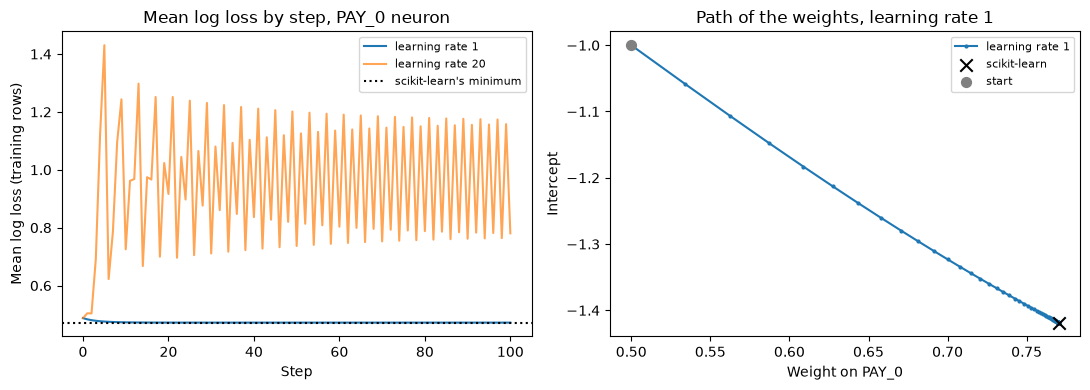

In [30]:
import matplotlib.pyplot as plt

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.plot(path.index, path["mean log loss"], label=f"learning rate {learning_rate:g}")
left.plot(range(len(too_large)), too_large, label="learning rate 20", alpha=0.7)
left.axhline(log_loss(outcome, reference.predict_proba(X_pay)[:, 1]), color="black", linestyle=":",
             label="scikit-learn's minimum")
left.set_title("Mean log loss by step, PAY_0 neuron")
left.set_xlabel("Step")
left.set_ylabel("Mean log loss (training rows)")
left.legend(fontsize=8)

right.plot(path["weight"], path["intercept"], marker=".", markersize=4, label=f"learning rate {learning_rate:g}")
right.scatter([w_sk], [b_sk], marker="x", s=80, color="black", label="scikit-learn", zorder=3)
right.scatter([w_start[0]], [b_start], marker="o", s=50, color="grey", label="start", zorder=3)
right.set_title("Path of the weights, learning rate 1")
right.set_xlabel("Weight on PAY_0")
right.set_ylabel("Intercept")
right.legend(fontsize=8)
plt.tight_layout()
plt.show()

* Left: at learning rate 1 the loss drops onto scikit-learn's minimum and stays; at 20 it jumps about above where it started. Right: each dot is one step. The first steps are long, then they crowd together near scikit-learn's cross, where the gradient is nearly zero.

Q. How does the hand-fitted neuron rank the validation accounts?

In [31]:
# the hand-fitted neuron's model probability of default on the validation rows
X_pay_valid = X_valid[["PAY_0"]].to_numpy(dtype="float64")
output_hand = 1 / (1 + np.exp(-(X_pay_valid @ np.array([w_hand]) + b_hand)))
print(f"PAY_0 neuron: validation ROC AUC {roc_auc_score(y_valid, output_hand):.4f}, "
      f"average precision {average_precision_score(y_valid, output_hand):.4f}")
print(f"Course 4 logistic regression on 19 columns: validation ROC AUC {roc_auc_score(y_valid, proba_logistic):.4f}")

PAY_0 neuron: validation ROC AUC 0.6834, average precision 0.4241
Course 4 logistic regression on 19 columns: validation ROC AUC 0.7190


* 0.6834 with one column against 0.7190 with all 19. With a positive weight the neuron ranks accounts exactly as `PAY_0` does, so this is `PAY_0`'s own ROC AUC; the other columns add the rest.

## 1.8 What Keras Automates

Keras builds the same neuron as a layer: `keras.layers.Dense(1, activation="sigmoid")` is one neuron with a weight per input, an intercept, and the sigmoid. `compile` chooses the loss and the optimizer; `fit` runs gradient descent, working out the gradient with a tape as in section 1.6 and taking steps as in section 1.7. Day 2 takes `compile` and `fit` apart line by line. Today, one check that it really is your step.

Q. Build the neuron in Keras, give it the starting weights, and run `fit` for one full-batch step of plain gradient descent (`SGD`) at learning rate 1.0. Does Keras land where `gradient_step` lands?

In [32]:
# seed before building any Keras model, so its numbers never depend on what ran before
keras.utils.set_random_seed(SEED)
neuron = keras.Sequential([keras.Input(shape=(1,)), keras.layers.Dense(1, activation="sigmoid", name="neuron")],
                          name="one_neuron")
# plain gradient descent at learning rate 1.0, and Keras's name for the mean log loss
neuron.compile(optimizer=keras.optimizers.SGD(learning_rate=1.0), loss="binary_crossentropy")
# the starting weight and intercept, in float32, Keras's precision
neuron.set_weights([np.array([[0.5]], dtype="float32"), np.array([-1.0], dtype="float32")])

# one epoch with a batch of all 18,000 rows is exactly one step
history = neuron.fit(X_pay.astype("float32"), outcome.astype("float32"), epochs=1, batch_size=len(X_pay),
                     shuffle=False, verbose=0)
kernel, bias = neuron.get_weights()
hand_w, hand_b = netkit.gradient_step(w_start, b_start, X_pay, outcome, 1.0)
print(f"Keras's loss before its step: {history.history['loss'][0]:.4f} (section 1.5: {loss_start:.4f})")
print(f"Keras after one step:  weight {kernel[0, 0]:.6f}, intercept {bias[0]:.6f}")
print(f"gradient_step:         weight {hand_w[0]:.6f}, intercept {hand_b:.6f}")
print(f"equal within 1e-6 (Keras works in float32): {abs(kernel[0, 0] - hand_w[0]) < 1e-6 and abs(bias[0] - hand_b) < 1e-6}")

Keras's loss before its step: 0.4876 (section 1.5: 0.4876)
Keras after one step:  weight 0.533916, intercept -1.058284
gradient_step:         weight 0.533916, intercept -1.058284
equal within 1e-6 (Keras works in float32): True


* Keras's loss before the step is section 1.5's 0.4876, and after one step its weight and intercept are `gradient_step`'s to 6 decimals. The step you wrote by hand is the step inside `fit`.
* `verbose=0` keeps Keras from printing a progress bar, which shows times that change every run. Every `fit`, `predict`, and `evaluate` in the course is written with it.
* What Keras adds is everything around the step: a gradient for every weight of every layer by the tape, mini-batches, epochs, smarter optimizers than plain steps, and the bookkeeping of the loss on rows held back to stop on. Days 2 to 5 add those one at a time.

> **STORY: the name for what Keras does to every weight.** In October 1986 David E. Rumelhart, Geoffrey E. Hinton, and Ronald J. Williams published a paper titled "Learning representations by back-propagating errors" in *Nature* (volume 323, issue 6088, pages 533 to 536). Its title holds the word the field uses for working out the gradient of the loss for every weight of a network, layer by layer from the output back to the inputs: back-propagation. Section 1.6 did it by hand for one neuron, and `tf.GradientTape` did it for you.
>
> Source (read 2026-10-06): the Crossref record of the paper, https://api.crossref.org/works/10.1038/323533a0, DOI https://doi.org/10.1038/323533a0. Only the title, authors, journal, volume, issue, pages, and date are taken from it; the paper itself was not read for this course.

## Excel Side by Side

Excel has no automatic differentiation and no network training: nothing in it works out a gradient for you the way `tf.GradientTape` does. What Excel can do is everything this notebook did by hand, because one neuron's output, its log loss, its gradient, and a gradient step are each a formula. Every formula below was typed into Excel by script on the 18,000 training rows (Excel 16.0 build 20430, 2026-10-06), with `PAY_0` pasted into column A and the outcome into column B of a sheet named `data`, the intercept in H1 and the weight in H2.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| The neuron's output | `1 / (1 + np.exp(-(X_pay @ w + b)))` | `=1/(1+EXP(-($H$1+$H$2*A2)))` in C2, filled down | equal to `tf.sigmoid` within 1e-12 |
| Log loss of one account | inside `mean_log_loss` | `=-(B2*LN(C2)+(1-B2)*LN(1-C2))` in D2, filled down | |
| Mean log loss | `netkit.mean_log_loss(outcome, p)` | `=AVERAGE(D2:D18001)` in H3 | 0.487621 |
| Gradient for the intercept | `log_loss_gradient(...)[1]` | `=SUMPRODUCT(C2:C18001-B2:B18001)/ROWS(A2:A18001)` in H6 | 0.058284 |
| Gradient for the weight | `log_loss_gradient(...)[0]` | `=SUMPRODUCT(C2:C18001-B2:B18001,A2:A18001)/ROWS(A2:A18001)` in H7 | -0.033916 |
| One step, learning rate in H5 | `netkit.gradient_step(...)` | `=$H$1-$H$5*$H$6` and `=$H$2-$H$5*$H$7` | -1.058284 and 0.533916 |
| 100 steps, one row each | the loop in section 1.7 | `=B2-$I$1*E2` and `=C2-$I$1*F2`, filled down | intercept -1.418545, weight 0.770210 |

**One neuron in a column.** With the weights in fixed cells (`$H$1`, `$H$2`), `=1/(1+EXP(-($H$1+$H$2*A2)))` is z and the sigmoid in one formula, filled down 18,000 rows. The log loss beside it and `AVERAGE` of that column are `mean_log_loss`.

**The gradient is two SUMPRODUCTs.** `SUMPRODUCT(C2:C18001-B2:B18001)` adds up p - y over the rows; with a second range, `SUMPRODUCT(C2:C18001-B2:B18001,A2:A18001)` adds up (p - y) x. Dividing by `ROWS(A2:A18001)` averages them: the formulas of section 1.6, cell for cell. One step is the weight minus the learning rate times its gradient.

**Gradient descent in rows.** On a second sheet, row 2 holds the starting intercept and weight (B2, C2) and each row below is the previous row minus the learning rate (in I1) times the previous row's gradients (E and F). Each gradient cell computes all 18,000 outputs inside one formula from its own row's weights:

`=SUMPRODUCT(1/(1+EXP(-(B2+C2*data!$A$2:$A$18001)))-data!$B$2:$B$18001,data!$A$2:$A$18001)/ROWS(data!$A$2:$A$18001)`

Filled down 100 rows, the last row is section 1.7's neuron. Excel did by formula what the loop did, step for step; the formulas only have to be written out by hand because Excel has no tape to work them out.

Q. Do Excel's numbers equal Python's?

In [33]:
# Excel's numbers, from the course's Excel check, beside Python's for the same rows
excel = {"mean log loss at the start": 0.48762066683889793,
         "gradient for the intercept": 0.058283734705355514,
         "gradient for the weight": -0.033915819140148955,
         "intercept after one step": -1.0582837347053555,
         "weight after one step": 0.533915819140149,
         "intercept after 100 steps": -1.418544517780347,
         "weight after 100 steps": 0.7702096127618195,
         "mean log loss after 100 steps": 0.4719934865933877}
python = {"mean log loss at the start": loss_start,
          "gradient for the intercept": gradient_b,
          "gradient for the weight": gradient_w[0],
          "intercept after one step": hand_b,
          "weight after one step": hand_w[0],
          "intercept after 100 steps": b_hand,
          "weight after 100 steps": w_hand,
          "mean log loss after 100 steps": path["mean log loss"].iloc[-1]}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-12"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-12
print(side_by_side.round(6).to_string())

                                  Excel    Python  within 1e-12
mean log loss at the start     0.487621  0.487621          True
gradient for the intercept     0.058284  0.058284          True
gradient for the weight       -0.033916 -0.033916          True
intercept after one step      -1.058284 -1.058284          True
weight after one step          0.533916  0.533916          True
intercept after 100 steps     -1.418545 -1.418545          True
weight after 100 steps         0.770210  0.770210          True
mean log loss after 100 steps  0.471993  0.471993          True


* Every number matches within 1e-12, including the end of a 100-step path, where small differences in the last digits could have grown and did not. The comparison is printed as "within 1e-12" rather than as the gaps, which are differences in the 14th to 16th decimal place between two ways of adding up 18,000 numbers.
* Excel's neuron output column matches TensorFlow's sigmoid on all 18,000 rows within 1e-12.

## Save the Day with Git

The work folder gets its own repository, as in Courses 4 and 5, and the first commit holds four files: Course 4's `mlkit.py` and Course 5's `ensemblekit.py`, unchanged, and the two new files that import them. Committing the earlier modules beside the new one puts the dependencies in the history: anyone who checks out this commit has everything `netkit` needs.

Q. Make the work folder a repository.

In [34]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [35]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course6_01_bumgunr1 and nowhere else


Q. Tell Git which files never to track: Python's bytecode cache, pytest's cache, Excel workbooks, and saved Keras models.

In [36]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx
*.keras

Writing .gitignore


In [37]:
# ?? marks an untracked file; the card file is a copy and stays untracked
!git -C "{work}" status --short

?? .gitignore
?? credit_card_default.csv
?? ensemblekit.py
?? mlkit.py
?? netkit.py
?? test_netkit.py


* `*.keras` is the file type Keras saves a fitted network in. A saved network is a result of running code, like a workbook, so it is never committed; the code that fits it is.
* The card file is a copy of the course's data, not today's work, so it is never committed.

Q. Commit `.gitignore`, the two earlier modules, and the two new files.

In [38]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py netkit.py test_netkit.py
!git -C "{work}" commit -q -m "Start netkit beside mlkit and ensemblekit: log loss, its gradient, a gradient step, 6 tests"
!git -C "{work}" log --oneline
!git -C "{work}" show --stat --format=%s HEAD

06aed03 Start netkit beside mlkit and ensemblekit: log loss, its gradient, a gradient step, 6 tests

Start netkit beside mlkit and ensemblekit: log loss, its gradient, a gradient step, 6 tests



 .gitignore     |   4 +
 ensemblekit.py | 624 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 mlkit.py       | 568 +++++++++++++++++++++++++++++++++++++++++++++++++++
 netkit.py      | 104 ++++++++++
 test_netkit.py |  87 ++++++++
 5 files changed, 1387 insertions(+)


Q. Start the experiment log: write today's validation metrics to `results.csv`, with 4 decimals.

In [39]:
# one row per model: its name, the rows scored, its ranking metrics, and its flags at the threshold
rows = []
for name, output in [("course4_logistic_regression", proba_logistic), ("pay_0_neuron_by_hand", output_hand)]:
    metrics = mlkit.classification_metrics(y_valid, (output >= 0.5).astype(int))
    rows.append({"model": name, "rows": "validation", "roc_auc": roc_auc_score(y_valid, output),
                 "average_precision": average_precision_score(y_valid, output), "threshold": 0.5, **metrics})
results = pd.DataFrame(rows)
# 4 decimals and LF line endings, so a later diff shows a real change and prints the same everywhere
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))
print(f"accuracy of flagging no account (all-zero baseline) on the validation rows: {1 - y_valid.mean():.4f}")

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
course4_logistic_regression,validation,0.7190,0.4946,0.5000,0.8123,0.7248,0.2442,0.3653
pay_0_neuron_by_hand,validation,0.6834,0.4241,0.5000,0.8160,0.6831,0.3135,0.4298

accuracy of flagging no account (all-zero baseline) on the validation rows: 0.7788


* Course 6's classification log keeps Course 5's nine columns: `model, rows, roc_auc, average_precision, threshold, accuracy, precision, recall, f1`. `rows` says which rows were scored (`validation` here; `cv` when a later day scores by folds). Today's threshold is 0.5 for both; from day 5 it comes from out-of-fold outputs on the training rows, by the recall rule.
* Accuracy is printed beside the all-zero baseline (0.7788) and never used to choose. The PAY_0 neuron is above the baseline on accuracy at 0.5 (0.8160, against 0.8123 for the logistic regression), yet it ranks the accounts far worse (0.6834 against 0.7190). Accuracy at one threshold says little about how a model ranks.

In [40]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: validation metrics of Course 4's logistic regression and the PAY_0 neuron fitted by hand"
!git -C "{work}" log --oneline

eebe1e3 Experiment log: validation metrics of Course 4's logistic regression and the PAY_0 neuron fitted by hand
06aed03 Start netkit beside mlkit and ensemblekit: log loss, its gradient, a gradient step, 6 tests


* Two commits: the code, then its results. Day 2's neuron in Keras adds a row, and `git diff results.csv` will show it.

## Bring It Home

Start Course 6 in your own `my_bondmath` folder, beside `mlkit.py` from Course 4 and `ensemblekit.py` from Course 5. Open a PowerShell terminal in VS Code.

**Step 1.** Install this course's packages into the course's `.venv`, once. The file adds TensorFlow and Keras to Course 5's pins and changes none of Course 5's versions. TensorFlow is a large download (its Windows wheel for Python 3.13 is about 350 MB), so give it a few minutes.

```powershell
Set-Location "$HOME\projects\python-fixed-income"
.\.venv\Scripts\Activate.ps1
python -m pip install -r course6_neural_networks\requirements.txt
python -c "import tensorflow as tf; print(tf.__version__)"
```

The last line prints the TensorFlow version. TensorFlow's Windows files rely on Microsoft's Visual C++ runtime, which pip does not install. If that line stops with an `ImportError` or `OSError` about a DLL that could not be loaded, install the Microsoft Visual C++ Redistributable (x64) from Microsoft's website and run the line again. This course has not tested a machine without it, so this is what to do if it happens, not a claim that it will.

**Step 2.** Go to your folder, check both earlier modules are there, and create the two new files. netkit's tests read no data file, so nothing needs copying.

```powershell
Set-Location "$HOME\projects\my_bondmath"
Test-Path mlkit.py, ensemblekit.py
code netkit.py
code test_netkit.py
```

`Test-Path` prints `True` twice. If either is `False`, finish that course's Bring It Home steps first, or write the file from this notebook's setup section.

**Step 3.** Paste the code of the three `%%writefile netkit.py` cells (sections 1.5, 1.6, and 1.7), without their first lines, into `netkit.py`, one after the other; do the same for the three `test_netkit.py` cells. Save both.

**Step 4.** Run the new tests.

```powershell
python -m pytest -q test_netkit.py
```

The last line says `6 passed`. netkit's header keeps TensorFlow's start-up notices quiet here too.

**Step 5.** Commit the code.

```powershell
git status --short
git add netkit.py test_netkit.py
git commit -m "Start netkit beside mlkit and ensemblekit: log loss, its gradient, a gradient step, 6 tests"
git log --oneline -3
```

**In Colab**, TensorFlow and Keras are usually installed already, and the setup cell stops with the install line if not. Download `netkit.py` and `test_netkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Rebuild Course 4's card rows with Course 5's function, and say why Course 6 never scores Course 4's test rows.
* Say what the setup cell's TensorFlow and thread lines do, and why a run on Windows uses the CPU.
* Make a tensor and read its shape and dtype, and cast between float32 and float64.
* Compute one neuron's output and its mean log loss by hand, with `mean_log_loss`.
* Work out the gradient of the mean log loss by hand with `log_loss_gradient`, and check it against `tf.GradientTape`.
* Fit one neuron by gradient descent with `gradient_step` until it is scikit-learn's logistic regression, and recognise a learning rate that is too large.
* Show that one step of Keras's `fit` is one of your steps.
* Commit the earlier modules beside the one that imports them, and start Course 6's experiment log.

Next, day 2: one neuron is a logistic regression, fitted in Keras on all 19 columns, and why its weights can differ from scikit-learn's while its loss does not.

## Exercises

The exercises use Course 4's 18,000 card training rows; the test rows are closed, the four person columns are not features, and every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the card rows, sets up `PAY_0` and the outcomes as in section 1.5, and defines `check`, a small function that marks your answers.

In [41]:
from sklearn.metrics import log_loss

# Course 4's training rows of the card file
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)

# section 1.5's inputs: PAY_0 as rows by one column, the outcomes, and the starting neuron
X_pay = X_train[["PAY_0"]].to_numpy(dtype="float64")
outcome = y_train.to_numpy(dtype="float64")
w_start, b_start = np.array([0.5]), -1.0


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Give the neuron a second input, `LIMIT_BAL` per 10,000 (the credit limit divided by 10,000), beside `PAY_0`. Work out the gradient of the mean log loss with `netkit.log_loss_gradient` at weights 0.5 for `PAY_0` and 0 for the limit, intercept -1.0. Store the gradient for the limit's weight in **ex1_gradient_limit**. Is it telling you to raise or lower that weight?

In [42]:
ex1_gradient_limit = ...

In [43]:
check("Exercise 1 the gradient for the limit", ex1_gradient_limit, 1.488818799099082)

Exercise 1 the gradient for the limit: not attempted yet


### Exercise 2

Q. Starting from w = 0.5, b = -1.0 on `PAY_0`, take 50 steps with `netkit.gradient_step` at each of the learning rates 0.1, 1, and 10. Store the mean log loss after the 50th step in **ex2_loss_01**, **ex2_loss_1**, and **ex2_loss_10**. Which rate ends lowest, and does any end above the start (0.4876)?

In [44]:
ex2_loss_01 = ...
ex2_loss_1 = ...
ex2_loss_10 = ...

In [45]:
check("Exercise 2 learning rate 0.1", ex2_loss_01, 0.476013911102858)
check("Exercise 2 learning rate 1", ex2_loss_1, 0.471993577517757)
check("Exercise 2 learning rate 10", ex2_loss_10, 0.5235015654578797)

Exercise 2 learning rate 0.1: not attempted yet
Exercise 2 learning rate 1: not attempted yet
Exercise 2 learning rate 10: not attempted yet


### Exercise 3

Q. Add a function to your module. `loss_path(w, b, X, y, learning_rate, steps)` takes `steps` gradient steps with `gradient_step` and returns a list of the mean log loss after each one; it refuses `steps` below 1 with `ValueError`. Write the docstring first. Then add `test_loss_path_hand`, which checks on `small_rows()` that five steps at learning rate 0.5 give five losses, that the first equals the loss after one `gradient_step`, that each is lower than the one before, and that `steps=0` raises. Run pytest, reload the module, and store the last number of `netkit.loss_path(w_start, b_start, X_pay, outcome, 1.0, 10)` in **ex3_loss_10**.

Write the function in the cell that starts with `%%writefile -a netkit.py` and the test in the one that starts with `%%writefile -a test_netkit.py`, and run each of those cells once.

In [46]:
%%writefile -a netkit.py


# Exercise 3: write loss_path(w, b, X, y, learning_rate, steps) below this line

Appending to netkit.py


In [47]:
%%writefile -a test_netkit.py


# Exercise 3: write test_loss_path_hand() below this line

Appending to test_netkit.py


In [48]:
# run pytest, reload the module, then run your function
ex3_loss_10 = ...

In [49]:
check("Exercise 3 loss_path after 10 steps", ex3_loss_10, 0.47299738536600244)

Exercise 3 loss_path after 10 steps: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that works out the gradient of one neuron's mean log loss, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
The gradient of the mean log loss of one sigmoid neuron.

    Inputs: w, one weight per column of X; b, the intercept; X, the rows (rows by columns); y, the outcomes.
    Output: (gradient for the weights, gradient for the intercept), averaged over the rows, as Keras averages
    the loss over a batch.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a gradient of the right shape with the right signs, and contains one bug.

In [50]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def neuron_gradient(w, b, X, y):
    """The gradient of the mean log loss of one sigmoid neuron.

    Inputs: w, one weight per column of X; b, the intercept; X, the rows (rows by columns); y, the outcomes.
    Output: (gradient for the weights, gradient for the intercept), averaged over the rows, as Keras averages
    the loss over a batch.
    """
    w, X, y = np.asarray(w, dtype=float), np.asarray(X, dtype=float), np.asarray(y, dtype=float)
    p = 1 / (1 + np.exp(-(X @ w + b)))
    # each row's error times its inputs, added up over the rows
    return (p - y) @ X, float(np.sum(p - y))

Q. Before you run the next cell: at learning rate 1.0, what will one step with this gradient do to the mean log loss of 0.4876? Section 1.7's first step lowered it.

In [51]:
ai_w, ai_b = neuron_gradient(w_start, b_start, X_pay, outcome)
print(f"neuron_gradient: weight {ai_w[0]:,.4f}, intercept {ai_b:,.4f}")
# one step at learning rate 1.0, then the loss
w_next, b_next = w_start - 1.0 * ai_w, b_start - 1.0 * ai_b
# the outputs end up at 0 or 1; tf.sigmoid computes them without numpy's overflow warning
p_next = tf.sigmoid(tf.constant(X_pay @ w_next + b_next)).numpy()
print(f"mean log loss after one step: {netkit.mean_log_loss(outcome, p_next):.4f}")

neuron_gradient: weight -610.4847, intercept 1,049.1072
mean log loss after one step: 2.8860


Q. Test the function against its docstring before you trust it: its gradient must equal TensorFlow's for the same mean log loss.

In [52]:
# the test, written from the docstring before the code is trusted
# TensorFlow's gradient of the same mean log loss, in float64
weights = tf.Variable(w_start)
intercept = tf.Variable(b_start, dtype=tf.float64)
with tf.GradientTape() as tape:
    output = tf.sigmoid(tf.linalg.matvec(tf.constant(X_pay), weights) + intercept)
    loss = tf.reduce_mean(-(outcome * tf.math.log(output) + (1 - outcome) * tf.math.log(1 - output)))
tape_w, tape_b = tape.gradient(loss, [weights, intercept])

ai_w, ai_b = neuron_gradient(w_start, b_start, X_pay, outcome)
assert abs(ai_w[0] - tape_w.numpy()[0]) < 1e-12, f"weight gradient {ai_w[0]:.4f}, TensorFlow's {tape_w.numpy()[0]:.6f}"
assert abs(ai_b - float(tape_b)) < 1e-12, f"intercept gradient {ai_b:.4f}, TensorFlow's {float(tape_b):.6f}"
print(f"neuron_gradient equal to TensorFlow's within 1e-12: weight {ai_w[0]:.6f}, intercept {ai_b:.6f}")

AssertionError: weight gradient -610.4847, TensorFlow's -0.033916

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's gradient for the weight at the starting neuron, `neuron_gradient(w_start, b_start, X_pay, outcome)[0][0]`, in **ex4_gradient_w**.

In [53]:
# fix the function above and run the test again, then store the answer
ex4_gradient_w = ...

In [54]:
check("Exercise 4 the fixed gradient for the weight", ex4_gradient_w, -0.03391581914014994)

Exercise 4 the fixed gradient for the weight: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```